   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.5 MB/s eta 0:00:00

=== STARTING RECURSIVE FEATURE ELIMINATION ===

Features: 33 | Test RMSE: 271.38 | Test MAE: 194.97 | Test R²: 0.554
  → Removing: CHROME_LENGTH (importance: 0.0003)

Features: 32 | Test RMSE: 268.51 | Test MAE: 191.30 | Test R²: 0.563
  → Removing: chemgroup3_score (importance: 0.0331)

Features: 31 | Test RMSE: 267.49 | Test MAE: 191.84 | Test R²: 0.566
  → Removing: POLY_LENGTH (importance: 0.0414)

Features: 30 | Test RMSE: 267.03 | Test MAE: 192.27 | Test R²: 0.568
  → Removing: rod_has_guides (importance: 0.0341)

Features: 29 | Test RMSE: 272.60 | Test MAE: 194.40 | Test R²: 0.550
  → Removing: ENDURALLOY_LENGTH (importance: 0.1122)

Features: 28 | Test RMSE: 269.88 | Test MAE: 191.64 | Test R²: 0.559
  → Removing: wellbore_category (importance: 0.1997)

Features: 27 | Test RMSE: 271.10 | Test MAE: 193.66 | Test R²: 0.554
  → Removing: H2S_CONCENTRATION (importance: 0.5131)

Features: 26 | Test RMSE: 

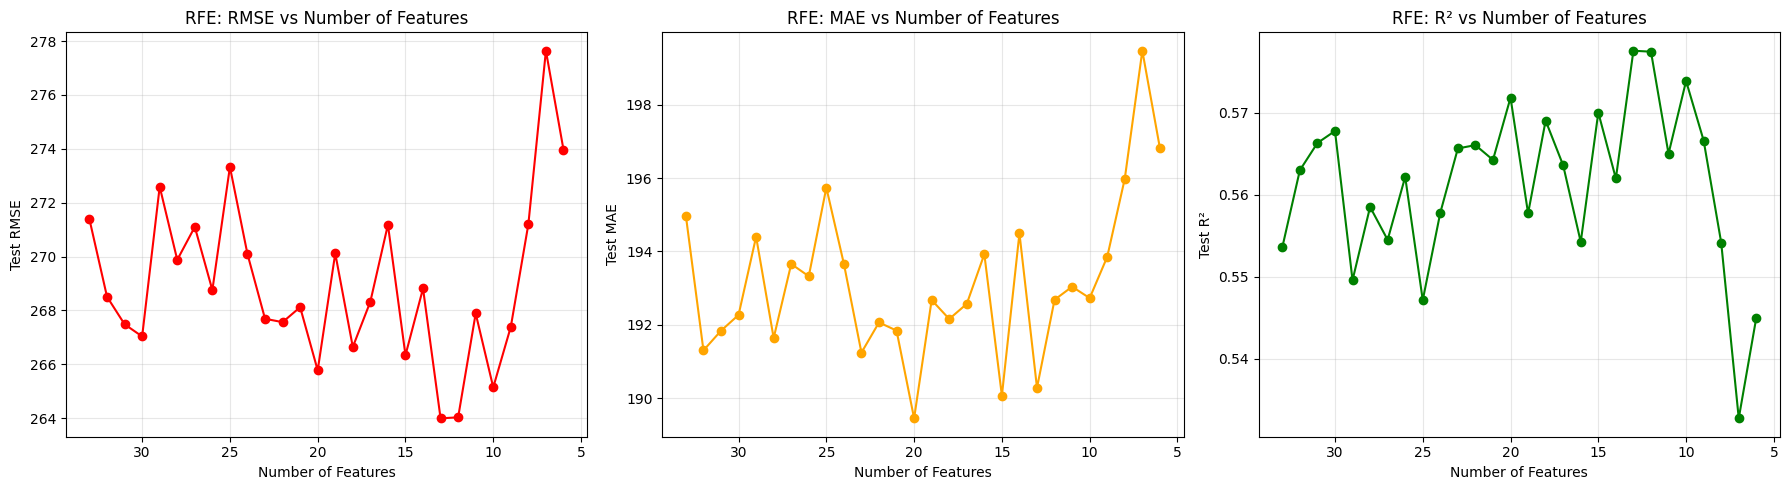


=== FINAL FEATURE IMPORTANCE ===
               feature  importance
4     chemgroup2_score   28.928256
3    AVG_LIQUID_VOLUME   20.753015
2  AVG_PRESSURE_TUBING   18.089457
0    GrossStrokeLength   17.051875
1    bha_configuration   15.177397


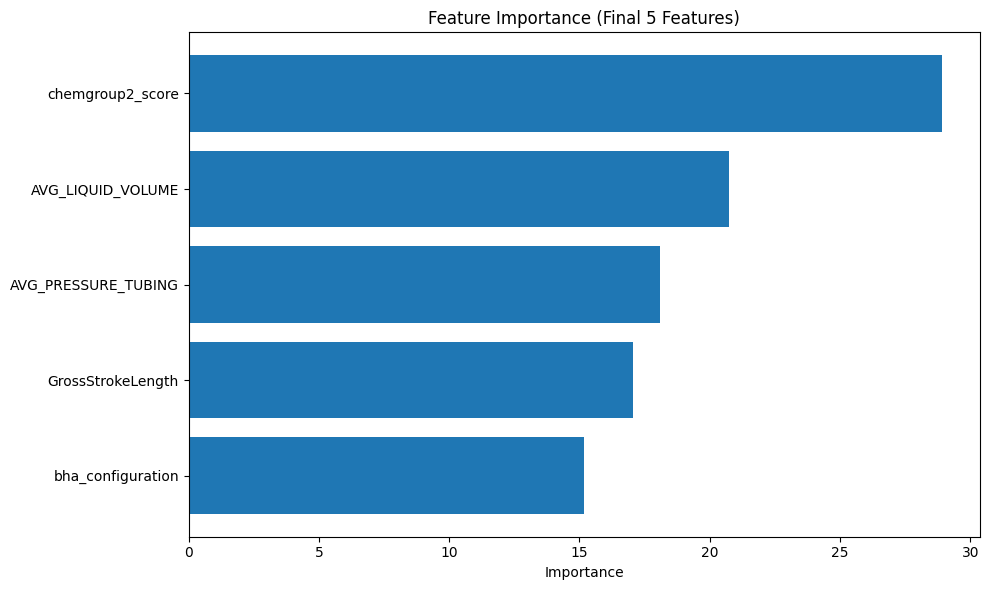

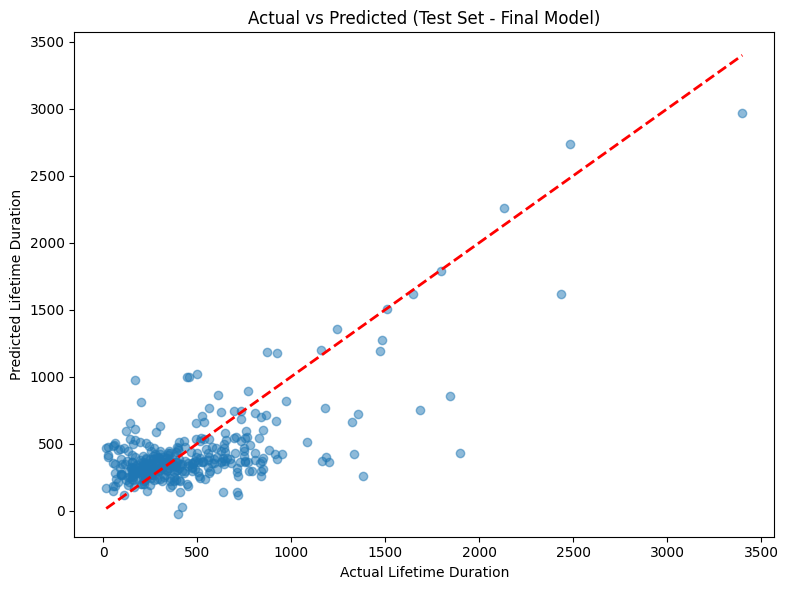


=== FEATURES REMOVED (in order) ===
1. CHROME_LENGTH
2. chemgroup3_score
3. POLY_LENGTH
4. rod_has_guides
5. ENDURALLOY_LENGTH
6. wellbore_category
7. H2S_CONCENTRATION
8. rod_sinker_type
9. MAX_INCLINATION
10. rod_make
11. DESANDDEGAS_TYP
12. YesterdaysAverageSPM
13. StrokeLength
14. max_unguided_dls
15. overall_max_sideload
16. Fillage
17. AVG_PRESS_FLOWLINE
18. NIPPLE_SET_DEPTH
19. AVG_DIFFERENTIAL_PRESSURE
20. rod_apigrade
21. gas_anchor_length
22. chemgroup1_score
23. packer_vs_tac
24. AVG_WATERSG
25. pump_bore
26. ROUTE
27. AVG_PRESSURE_CASING
28. WaterRatio

=== RFE PERFORMANCE SUMMARY ===
 n_features  test_rmse   test_mae  test_r2           removed_feature
         33 271.378929 194.969578 0.553593             CHROME_LENGTH
         32 268.508456 191.302424 0.562986          chemgroup3_score
         31 267.486774 191.838594 0.566306               POLY_LENGTH
         30 267.034858 192.269553 0.567770            rod_has_guides
         29 272.595437 194.402005 0.549581        

In [1]:
### CatBoost Recursive Feature Elimination
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/PandaKnee/Rod-Pump-Failure-Analysis/refs/heads/main/preFS_df.csv')
df = df[df['FAILED'] == 1]
df.drop(['UWI','tbguid','lifetime_start','FAILURETYPE'], axis = 1, inplace = True)
X = df.drop(['FAILED','lifetime_duration_days'], axis = 1)
y = df['lifetime_duration_days']
cat = ['bha_configuration', 'wellbore_category','packer_vs_tac', 'rod_sinker_type', 'rod_make','rod_apigrade','rod_has_guides','DESANDDEGAS_TYP', 'ROUTE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 21)

#The following code used for Recursive Feature Elimination was generated by AI:

# ============================================
# RECURSIVE FEATURE ELIMINATION
# ============================================

# Store feature indices for categorical features
cat_indices = [X_train.columns.get_loc(c) for c in cat if c in X_train.columns]

features = list(X_train.columns)
removed_features = []
performance_history = []

print("\n=== STARTING RECURSIVE FEATURE ELIMINATION ===\n")

while len(features) > 5:  # Stop when you have 5 features left (adjust as needed)

    # Update categorical feature indices for current feature set
    current_cat_indices = [i for i, f in enumerate(features) if f in cat]

    # Train model with current features
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=4,
        l2_leaf_reg=3,
        cat_features=current_cat_indices,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=21,
        verbose=0,
        bagging_temperature=1,
        early_stopping_rounds=30
    )


    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    model.fit(X_train_subset, y_train, eval_set=(X_test_subset, y_test))

    # Evaluate
    y_pred_test = model.predict(X_test_subset)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)

    # Get feature importance
    feature_importance = model.get_feature_importance()
    importance_dict = dict(zip(features, feature_importance))

    # Find least important feature
    least_important = min(importance_dict, key=importance_dict.get)
    least_importance_value = importance_dict[least_important]

    # Record performance
    performance_history.append({
        'n_features': len(features),
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'removed_feature': least_important,
        'removed_importance': least_importance_value
    })

    print(f"Features: {len(features)} | Test RMSE: {test_rmse:.2f} | Test MAE: {test_mae:.2f} | Test R²: {test_r2:.3f}")
    print(f"  → Removing: {least_important} (importance: {least_importance_value:.4f})\n")

    # Remove least important feature
    removed_features.append(least_important)
    features.remove(least_important)

# ============================================
# FINAL MODEL WITH SELECTED FEATURES
# ============================================

print(f"\n=== FINAL FEATURE SET ({len(features)} features) ===")
print(features)

final_cat_indices = [i for i, f in enumerate(features) if f in cat]

final_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3,
    cat_features=final_cat_indices,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=21,
    verbose=100,
    bagging_temperature=1,
    early_stopping_rounds=30
)

X_train_final = X_train[features]
X_test_final = X_test[features]

final_model.fit(X_train_final, y_train)

y_pred_train = final_model.predict(X_train_final)
y_pred_test = final_model.predict(X_test_final)

print("\n=== FINAL MODEL PERFORMANCE ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"Train R²: {r2_score(y_train, y_pred_train):.3f}")
print(f"Test R²: {r2_score(y_test, y_pred_test):.3f}")

# ============================================
# VISUALIZATIONS
# ============================================

# Performance vs number of features
perf_df = pd.DataFrame(performance_history)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(perf_df['n_features'], perf_df['test_rmse'], marker='o', color='red')
ax1.set_xlabel('Number of Features')
ax1.set_ylabel('Test RMSE')
ax1.set_title('RFE: RMSE vs Number of Features')
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

ax2.plot(perf_df['n_features'], perf_df['test_mae'], marker='o', color='orange')
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Test MAE')
ax2.set_title('RFE: MAE vs Number of Features')
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

ax3.plot(perf_df['n_features'], perf_df['test_r2'], marker='o', color='green')
ax3.set_xlabel('Number of Features')
ax3.set_ylabel('Test R²')
ax3.set_title('RFE: R² vs Number of Features')
ax3.grid(True, alpha=0.3)
ax3.invert_xaxis()

plt.tight_layout()
plt.show()

# Feature importance of final model
feature_importance = final_model.get_feature_importance()
importance_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n=== FINAL FEATURE IMPORTANCE ===")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title(f'Feature Importance (Final {len(features)} Features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Show removed features in order
print("\n=== FEATURES REMOVED (in order) ===")
for i, feat in enumerate(removed_features, 1):
    print(f"{i}. {feat}")

# Show performance summary table
print("\n=== RFE PERFORMANCE SUMMARY ===")
print(perf_df[['n_features', 'test_rmse', 'test_mae', 'test_r2', 'removed_feature']].to_string(index=False))


PREPARING DATA FOR MUTUAL INFORMATION ANALYSIS
Failed pumps: (1704, 39)
✓ Dropped columns: ['UWI', 'tbguid', 'lifetime_start', 'FAILURETYPE']
Features (X): (1704, 33)
Target (y): (1704, 1)
Categorical features: 8
Train set: (1363, 33)
Test set: (341, 33)

ENCODING CATEGORICAL FEATURES
✓ Encoded: bha_configuration
✓ Encoded: wellbore_category
✓ Encoded: packer_vs_tac
✓ Encoded: rod_sinker_type
✓ Encoded: rod_make
✓ Encoded: rod_apigrade
✓ Encoded: rod_has_guides
✓ Encoded: DESANDDEGAS_TYP

HANDLING MISSING VALUES

⚠️  WARNING: Missing values detected
GrossStrokeLength            729
Fillage                      384
YesterdaysAverageSPM         488
max_unguided_dls              22
gas_anchor_length              1
MAX_INCLINATION               26
AVG_PRESS_FLOWLINE           614
AVG_PRESSURE_TUBING           22
AVG_PRESSURE_CASING           16
AVG_DIFFERENTIAL_PRESSURE     19
AVG_WATERSG                  451
overall_max_sideload         425
NIPPLE_SET_DEPTH               9
pump_bore     

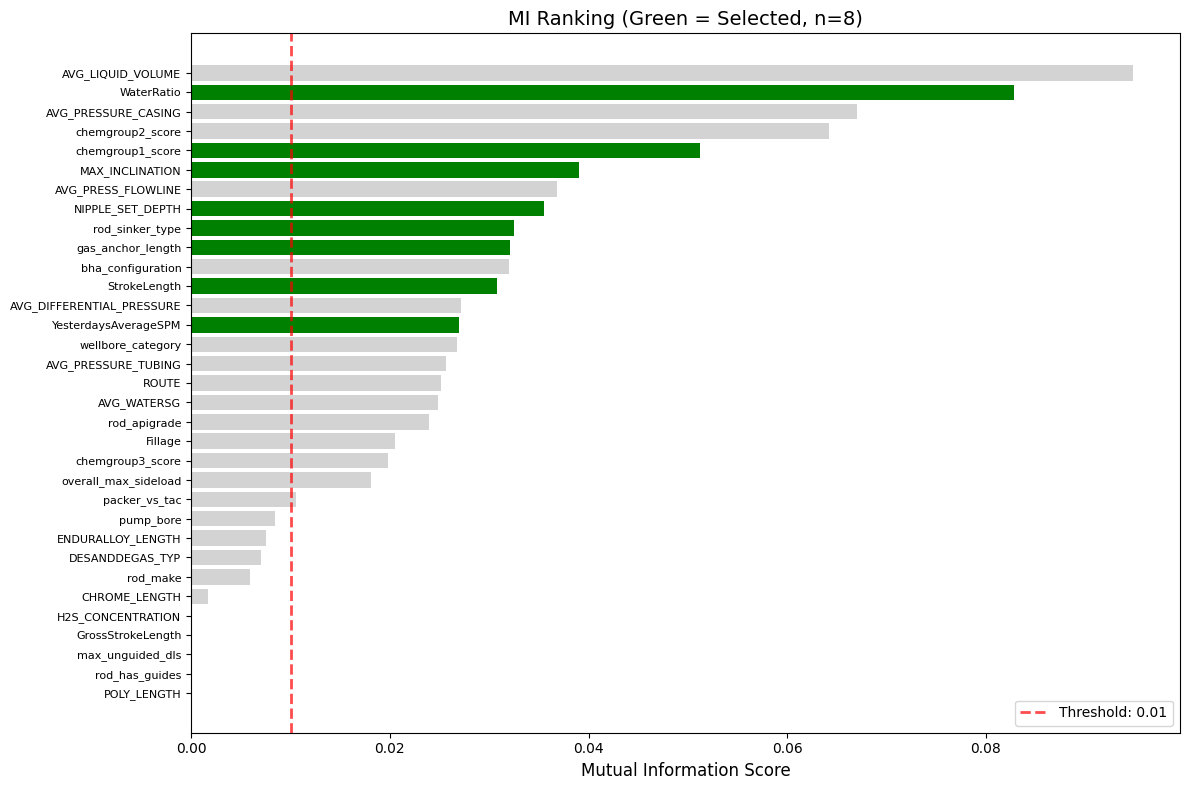

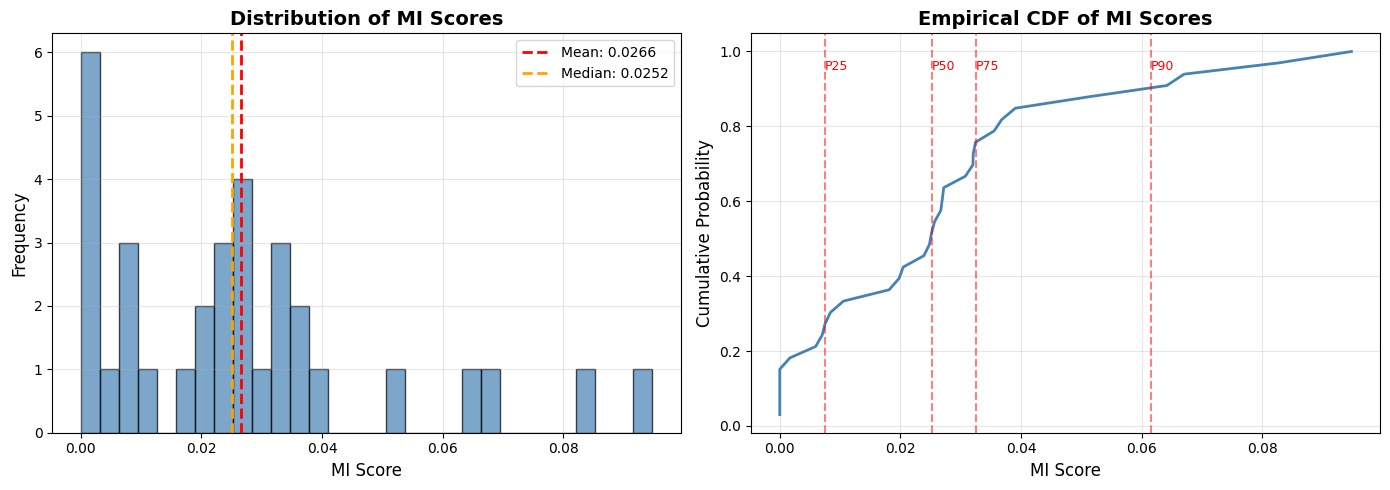

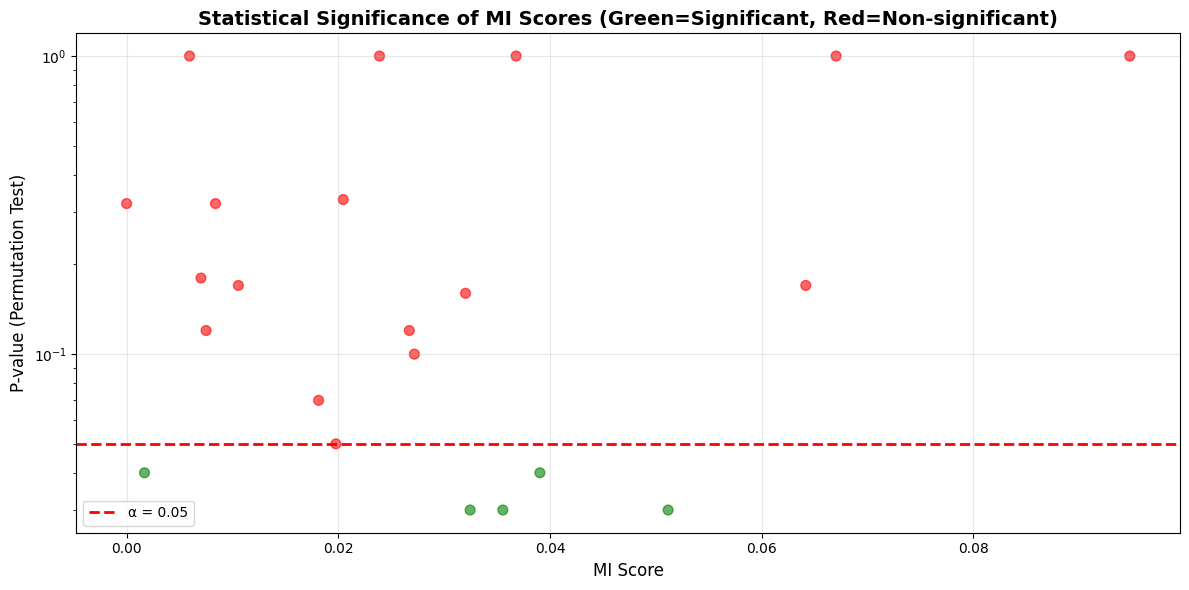


✓ MUTUAL INFORMATION ANALYSIS COMPLETE


In [2]:
# ============================================
# MUTUAL INFORMATION FEATURE SELECTION (Generated by AI)
# ============================================
# CRITICAL CONSTRAINTS:
# - This code uses ONLY Mutual Information for feature analysis
# - NO correlation metrics (Pearson, Spearman, partial correlation)
# - NO predictive models (CatBoost, XGBoost, LinearRegression, etc.)
# - ALL statistical validation is MI-based (permutation tests, bootstrap)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from itertools import combinations
import time

df = pd.read_csv('https://raw.githubusercontent.com/PandaKnee/Rod-Pump-Failure-Analysis/refs/heads/main/preFS_df.csv')

print("\n" + "="*70)
print("PREPARING DATA FOR MUTUAL INFORMATION ANALYSIS")
print("="*70)

# Filter to failed pumps only
df_failed = df[df['FAILED'] == 1].copy()
print(f"Failed pumps: {df_failed.shape}")

# ============================================
# ✅ FIXED: Drop columns not needed for modeling (handle missing columns)
# ============================================
cols_to_drop = ['UWI', 'tbguid', 'lifetime_start', 'FAILURETYPE', 'sample_weight']
cols_to_drop = [col for col in cols_to_drop if col in df_failed.columns]
df_failed.drop(cols_to_drop, axis=1, inplace=True)
print(f"✓ Dropped columns: {cols_to_drop}")

# Define features and target
X = df_failed.drop(['FAILED','lifetime_duration_days'], axis=1)
y = df_failed[['lifetime_duration_days']]

# Define categorical features
cat = ['bha_configuration', 'wellbore_category', 'packer_vs_tac',
       'rod_sinker_type', 'rod_make', 'rod_apigrade',
       'rod_has_guides', 'DESANDDEGAS_TYP']

# Validate categorical features exist
cat = [c for c in cat if c in X.columns]

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Categorical features: {len(cat)}")

# ============================================
# TRAIN/TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=21)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# ============================================
# CATEGORICAL ENCODING FOR MI
# ============================================
print("\n" + "="*70)
print("ENCODING CATEGORICAL FEATURES")
print("="*70)

X_train_encoded = X_train.copy()
for col in cat:
    if col in X_train_encoded.columns:
        X_train_encoded[col] = pd.Categorical(X_train_encoded[col]).codes
        print(f"✓ Encoded: {col}")

# Convert y to 1D array
y_train_1d = y_train.values.ravel()

# ============================================
# MISSING VALUE HANDLING
# ============================================
print("\n" + "="*70)
print("HANDLING MISSING VALUES")
print("="*70)

missing_report = X_train_encoded.isnull().sum()
if missing_report.sum() > 0:
    print("\n⚠️  WARNING: Missing values detected")
    print(missing_report[missing_report > 0].to_string())

    print("\nImputing missing values...")
    for col in X_train_encoded.columns:
        if X_train_encoded[col].isnull().sum() > 0:
            if col in cat:
                mode_val = X_train_encoded[col].mode()
                fill_val = mode_val[0] if len(mode_val) > 0 else -1
                X_train_encoded.loc[:, col] = X_train_encoded[col].fillna(fill_val)
            else:
                median_val = X_train_encoded[col].median()
                X_train_encoded.loc[:, col] = X_train_encoded[col].fillna(median_val)

    print(f"✓ Missing values imputed")
    print(f"✓ Remaining NaNs: {X_train_encoded.isnull().sum().sum()}")
else:
    print("✓ No missing values detected")

# Check for constant features
constant_features = X_train_encoded.columns[X_train_encoded.nunique() <= 1]
if len(constant_features) > 0:
    print(f"\n⚠️  WARNING: Constant features detected: {list(constant_features)}")
    print("   These will have MI = 0")

# ============================================
# TASK TYPE DETECTION (Classification vs Regression)
# ============================================
print("\n" + "="*70)
print("TASK TYPE DETECTION")
print("="*70)

# Configuration override (set manually if auto-detection fails)
IS_CLASSIFICATION = None  # Set True/False to override

if IS_CLASSIFICATION is not None:
    is_classification = IS_CLASSIFICATION
    print(f"✓ Task type manually set: {'CLASSIFICATION' if is_classification else 'REGRESSION'}")
else:
    # Auto-detect based on dtype and cardinality
    y_dtype = y_train_1d.dtype
    n_unique = len(np.unique(y_train_1d))

    if y_dtype in ['object', 'category', 'bool']:
        is_classification = True
        detection_reason = "dtype is categorical/boolean"
    elif y_dtype in ['int64', 'int32', 'int16', 'int8']:
        if n_unique <= 10:
            is_classification = True
            detection_reason = f"integer with {n_unique} unique values (≤10)"
        else:
            is_classification = False
            detection_reason = f"integer with {n_unique} unique values (>10)"
    else:  # float
        is_classification = False
        detection_reason = "dtype is float (continuous)"

    print(f"✓ Task type auto-detected: {'CLASSIFICATION' if is_classification else 'REGRESSION'}")
    print(f"  Reason: {detection_reason}")
    print(f"  Target dtype: {y_dtype}, unique values: {n_unique}")

# Select MI function
if is_classification:
    mi_function = mutual_info_classif
    print(f"  Using: mutual_info_classif")
else:
    mi_function = mutual_info_regression
    print(f"  Using: mutual_info_regression")

# ============================================
# MUTUAL INFORMATION COMPUTATION
# ============================================
print("\n" + "="*70)
print("COMPUTING MUTUAL INFORMATION SCORES")
print("="*70)

MI_N_NEIGHBORS = 3
MI_RANDOM_STATE = 21

print(f"Parameters: n_neighbors={MI_N_NEIGHBORS}, random_state={MI_RANDOM_STATE}")
print("Computing MI scores...")

mi_scores = mi_function(
    X_train_encoded,
    y_train_1d,
    random_state=MI_RANDOM_STATE,
    n_neighbors=MI_N_NEIGHBORS
)

# Create MI ranking
mi_ranking = pd.DataFrame({
    'feature': X_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

mi_ranking['rank'] = range(1, len(mi_ranking) + 1)

print("✓ MI computation complete")
print(f"\nMI Score Statistics:")
print(f"  Maximum: {mi_ranking['mi_score'].max():.6f}")
print(f"  Minimum: {mi_ranking['mi_score'].min():.6f}")
print(f"  Mean:    {mi_ranking['mi_score'].mean():.6f}")
print(f"  Median:  {mi_ranking['mi_score'].median():.6f}")
print(f"  Features with MI > 0: {(mi_ranking['mi_score'] > 0).sum()} / {len(mi_ranking)}")
print(f"  Features with MI = 0: {(mi_ranking['mi_score'] == 0).sum()}")

# ============================================
# STATISTICAL SIGNIFICANCE TESTING (Permutation Test)
# ============================================
print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE TESTING (Permutation Test)")
print("="*70)

N_PERMUTATIONS = 100  # Increase to 1000 for production
ALPHA = 0.05

print(f"Running permutation test with {N_PERMUTATIONS} permutations...")
print(f"This validates whether MI scores are statistically significant vs. random noise.")

perm_start = time.time()

# Store null distribution for each feature
null_distributions = np.zeros((len(X_train.columns), N_PERMUTATIONS))

for perm_idx in range(N_PERMUTATIONS):
    # Shuffle target to break relationship
    y_shuffled = np.random.permutation(y_train_1d)

    # Recompute MI scores on shuffled data
    mi_null = mi_function(
        X_train_encoded,
        y_shuffled,
        n_neighbors=MI_N_NEIGHBORS,
        random_state=MI_RANDOM_STATE + perm_idx
    )

    null_distributions[:, perm_idx] = mi_null

    if (perm_idx + 1) % 20 == 0:
        print(f"  Progress: {perm_idx + 1}/{N_PERMUTATIONS} permutations complete")

perm_elapsed = time.time() - perm_start

# Compute p-values: fraction of null MI scores >= observed MI
p_values = np.mean(null_distributions >= mi_scores[:, np.newaxis], axis=1)

# Add to ranking table
mi_ranking['p_value'] = p_values
mi_ranking['significant'] = p_values < ALPHA

# Bonferroni correction for multiple testing
from statsmodels.stats.multitest import multipletests
_, p_values_bonf, _, _ = multipletests(p_values, alpha=ALPHA, method='bonferroni')
mi_ranking['p_value_bonf'] = p_values_bonf
mi_ranking['significant_bonf'] = p_values_bonf < ALPHA

print(f"\n✓ Permutation test completed in {perm_elapsed:.1f} seconds")
print(f"\nSignificance Results:")
print(f"  Significant features (p < {ALPHA}):          {mi_ranking['significant'].sum()} / {len(mi_ranking)}")
print(f"  Significant (Bonferroni-corrected):          {mi_ranking['significant_bonf'].sum()} / {len(mi_ranking)}")
print(f"  Non-significant features:                    {(~mi_ranking['significant']).sum()}")

# Show features with non-significant MI
non_sig = mi_ranking[~mi_ranking['significant']][['rank', 'feature', 'mi_score', 'p_value']].head(10)
if len(non_sig) > 0:
    print(f"\n⚠️  Top 10 non-significant features (may be random noise):")
    print(non_sig.to_string(index=False))

# ============================================
# BOOTSTRAP CONFIDENCE INTERVALS
# ============================================
print("\n" + "="*70)
print("BOOTSTRAP CONFIDENCE INTERVALS FOR MI SCORES")
print("="*70)

N_BOOTSTRAP = 50  # Increase to 100-200 for production
CI_LEVEL = 0.95

print(f"Computing {CI_LEVEL*100:.0f}% confidence intervals via {N_BOOTSTRAP} bootstrap samples...")

bootstrap_mi = np.zeros((len(X_train.columns), N_BOOTSTRAP))

for boot_idx in range(N_BOOTSTRAP):
    # Resample with replacement
    boot_indices = np.random.choice(len(X_train_encoded), size=len(X_train_encoded), replace=True)
    X_boot = X_train_encoded.iloc[boot_indices]
    y_boot = y_train_1d[boot_indices]

    # Recompute MI
    mi_boot = mi_function(
        X_boot, y_boot,
        n_neighbors=MI_N_NEIGHBORS,
        random_state=MI_RANDOM_STATE + boot_idx
    )

    bootstrap_mi[:, boot_idx] = mi_boot

# Compute percentile-based CI
alpha = (1 - CI_LEVEL) / 2
mi_ranking['mi_ci_lower'] = np.percentile(bootstrap_mi, alpha * 100, axis=1)
mi_ranking['mi_ci_upper'] = np.percentile(bootstrap_mi, (1 - alpha) * 100, axis=1)
mi_ranking['mi_ci_width'] = mi_ranking['mi_ci_upper'] - mi_ranking['mi_ci_lower']

print(f"✓ Bootstrap CIs computed")
print(f"\nCI Width Statistics (indicates estimation uncertainty):")
print(f"  Mean CI width: {mi_ranking['mi_ci_width'].mean():.6f}")
print(f"  Max CI width:  {mi_ranking['mi_ci_width'].max():.6f}")

# ============================================
# MUTUAL INFORMATION RANKING
# ============================================
print("\n" + "="*70)
print("MUTUAL INFORMATION RANKING (with Statistical Validation)")
print("="*70)

# Reorder columns for display
display_cols = ['rank', 'feature', 'mi_score', 'mi_ci_lower', 'mi_ci_upper', 'p_value', 'significant']
print(mi_ranking[display_cols].to_string(index=False))

# ============================================
# FEATURE SELECTION
# ============================================
print("\n" + "="*70)
print("FEATURE SELECTION")
print("="*70)

# MI Score Interpretation Guide:
# - MI = 0:        No mutual information (independent)
# - MI < 0.02:     Very weak dependence (may be noise)
# - MI 0.02-0.10:  Weak dependence (low predictive value)
# - MI 0.10-0.30:  Moderate dependence (useful feature)
# - MI 0.30-0.70:  Strong dependence (important feature)
# - MI > 0.70:     Very strong dependence (critical feature)

TOP_K = 15
MI_THRESHOLD = 0.01
REQUIRE_SIGNIFICANCE = True  # Only select statistically significant features

print(f"Selection criteria:")
print(f"  TOP_K: {TOP_K}")
print(f"  MI_THRESHOLD: {MI_THRESHOLD}")
print(f"  REQUIRE_SIGNIFICANCE: {REQUIRE_SIGNIFICANCE}")

selected_features = list(mi_ranking['feature'])

# Apply TOP_K filter
if TOP_K is not None:
    selected_features = selected_features[:TOP_K]
    print(f"\n✓ TOP_K filter: {len(selected_features)} features")

# Apply MI_THRESHOLD filter
if MI_THRESHOLD is not None:
    selected_features = [f for f in selected_features
                        if mi_ranking[mi_ranking['feature'] == f]['mi_score'].values[0] >= MI_THRESHOLD]
    print(f"✓ MI_THRESHOLD filter: {len(selected_features)} features")

# Apply significance filter
if REQUIRE_SIGNIFICANCE:
    selected_features = [f for f in selected_features
                        if mi_ranking[mi_ranking['feature'] == f]['significant'].values[0]]
    print(f"✓ Significance filter: {len(selected_features)} features (p < {ALPHA})")

# ============================================
# MI-BASED REDUNDANCY ANALYSIS
# ============================================
print("\n" + "="*70)
print("MI-BASED REDUNDANCY ANALYSIS (Pairwise MI Among Selected Features)")
print("="*70)

if len(selected_features) > 1:
    print(f"\nComputing pairwise MI among {len(selected_features)} selected features...")
    print("This identifies potentially redundant feature pairs.")

    REDUNDANCY_THRESHOLD = 0.15  # High MI between features = potential redundancy
    redundant_pairs = []

    for feat1, feat2 in combinations(selected_features, 2):
        mi_between = mi_function(
            X_train_encoded[[feat1]].values,
            X_train_encoded[feat2].values,
            n_neighbors=MI_N_NEIGHBORS,
            random_state=MI_RANDOM_STATE
        )[0]

        if mi_between > REDUNDANCY_THRESHOLD:
            feat1_mi_target = mi_ranking[mi_ranking['feature']==feat1]['mi_score'].values[0]
            feat2_mi_target = mi_ranking[mi_ranking['feature']==feat2]['mi_score'].values[0]

            redundant_pairs.append({
                'feature_1': feat1,
                'feature_2': feat2,
                'mi_between_features': mi_between,
                'mi_feat1_with_target': feat1_mi_target,
                'mi_feat2_with_target': feat2_mi_target,
                'keep': feat1 if feat1_mi_target > feat2_mi_target else feat2,
                'drop': feat2 if feat1_mi_target > feat2_mi_target else feat1
            })

    if len(redundant_pairs) > 0:
        print(f"\n⚠️  {len(redundant_pairs)} potentially redundant pairs detected:")
        print(f"   (MI between features > {REDUNDANCY_THRESHOLD})")
        redundant_df = pd.DataFrame(redundant_pairs).sort_values('mi_between_features', ascending=False)
        print(redundant_df.to_string(index=False))
        print("\n  Recommendation: Consider removing features in 'drop' column (lower MI with target).")
    else:
        print(f"\n✓ No high MI between features (all pairwise MI < {REDUNDANCY_THRESHOLD})")
        print("  Selected features are relatively independent.")
else:
    print("\n✓ Only 1 feature selected - no redundancy check needed")

# ============================================
# SELECTED FEATURES SUMMARY
# ============================================
print("\n" + "="*70)
print(f"SELECTED FEATURES ({len(selected_features)} total)")
print("="*70)

selected_cat_features = [f for f in selected_features if f in cat]
selected_num_features = [f for f in selected_features if f not in cat]

print(f"\nCategorical: {len(selected_cat_features)}")
print(f"Numerical: {len(selected_num_features)}\n")

for i, feat in enumerate(selected_features, 1):
    feat_info = mi_ranking[mi_ranking['feature'] == feat].iloc[0]
    mi_val = feat_info['mi_score']
    p_val = feat_info['p_value']
    ci_lower = feat_info['mi_ci_lower']
    ci_upper = feat_info['mi_ci_upper']
    feat_type = "CAT" if feat in cat else "NUM"
    sig_marker = "✓" if feat_info['significant'] else "✗"

    print(f"{i:2d}. [{feat_type}] {feat:40s} MI: {mi_val:.6f} [{ci_lower:.6f}, {ci_upper:.6f}] p={p_val:.4f} {sig_marker}")

selected_cat_indices = [i for i, f in enumerate(selected_features) if f in cat]

print("\n" + "="*70)
print("OUTPUTS FOR DOWNSTREAM MODELING")
print("="*70)
print(f"✓ selected_features: {len(selected_features)} features")
print(f"✓ selected_cat_indices: {selected_cat_indices}")
print(f"✓ mi_ranking: Full DataFrame with MI scores, CIs, and p-values")

# ============================================
# VISUALIZATIONS
# ============================================
print("\n" + "="*70)
print("GENERATING MI VISUALIZATIONS")
print("="*70)

# Figure 1: MI Ranking Bar Chart
plt.figure(figsize=(12, 8))
colors = ['green' if f in selected_features else 'lightgray' for f in mi_ranking['feature']]
plt.barh(range(len(mi_ranking)), mi_ranking['mi_score'], color=colors)
plt.yticks(range(len(mi_ranking)), mi_ranking['feature'], fontsize=8)
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title(f'MI Ranking (Green = Selected, n={len(selected_features)})', fontsize=14)
if MI_THRESHOLD and MI_THRESHOLD > 0:
    plt.axvline(MI_THRESHOLD, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Threshold: {MI_THRESHOLD}')
    plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Figure 2: MI Distribution (Histogram + CDF)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(mi_ranking['mi_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(mi_ranking['mi_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {mi_ranking["mi_score"].mean():.4f}')
axes[0].axvline(mi_ranking['mi_score'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {mi_ranking["mi_score"].median():.4f}')
axes[0].set_xlabel('MI Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of MI Scores', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# CDF
mi_sorted = np.sort(mi_ranking['mi_score'])
cdf = np.arange(1, len(mi_sorted)+1) / len(mi_sorted)
axes[1].plot(mi_sorted, cdf, linewidth=2, color='steelblue')
axes[1].set_xlabel('MI Score', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('Empirical CDF of MI Scores', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add percentile lines
for percentile in [25, 50, 75, 90]:
    mi_val = np.percentile(mi_ranking['mi_score'], percentile)
    axes[1].axvline(mi_val, color='red', linestyle='--', alpha=0.5)
    axes[1].text(mi_val, 0.95, f'P{percentile}', fontsize=9, color='red')

plt.tight_layout()
plt.show()

# Figure 3: Statistical Significance Visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

colors = ['green' if sig else 'red' for sig in mi_ranking['significant']]
ax.scatter(mi_ranking['mi_score'], mi_ranking['p_value'], c=colors, alpha=0.6, s=50)
ax.axhline(ALPHA, color='red', linestyle='--', linewidth=2, label=f'α = {ALPHA}')
ax.set_xlabel('MI Score', fontsize=12)
ax.set_ylabel('P-value (Permutation Test)', fontsize=12)
ax.set_title('Statistical Significance of MI Scores (Green=Significant, Red=Non-significant)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ MUTUAL INFORMATION ANALYSIS COMPLETE")
print("="*70)

In [3]:
#Post Feature Selection df
df = pd.read_csv('https://raw.githubusercontent.com/PandaKnee/Rod-Pump-Failure-Analysis/refs/heads/main/preFS_df.csv')
df.drop(['AVG_DIFFERENTIAL_PRESSURE','NIPPLE_SET_DEPTH','StrokeLength','rod_apigrade','pump_bore','rod_make','rod_sinker_type','overall_max_sideload','max_unguided_dls','wellbore_category','packer_vs_tac','DESANDDEGAS_TYP','chemgroup3_score','H2S_CONCENTRATION','POLY_LENGTH','rod_has_guides','ENDURALLOY_LENGTH','CHROME_LENGTH'], axis=1, inplace=True)

#export
from google.colab import files
df.to_csv('postFS_df.csv', index=False)
#files.download('postFS_df.csv') #uncomment to download
df.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,UWI,tbguid,lifetime_start,FAILURETYPE,GrossStrokeLength,Fillage,YesterdaysAverageSPM,bha_configuration,gas_anchor_length,MAX_INCLINATION,...,AVG_PRESSURE_TUBING,AVG_PRESSURE_CASING,AVG_LIQUID_VOLUME,AVG_WATERSG,ROUTE,FAILED,lifetime_duration_days,WaterRatio,chemgroup1_score,chemgroup2_score
0,175-58-0111,GB55QFGB46756147811400,2014-05-02 00:00:00,Tubing,108.135619,91.410156,6.000000,TAC_ABOVE_NIP,19.27,2.43,...,74.293221,52.782752,109.325929,1.04,900,1,1708.42,0.536177,1.0,1.0
1,333-68-3523,GB29QCCC14341267287129,2018-01-28 14:00:00,Tubing,173.462417,2.500000,0.000000,TAC_BELOW_NIP,17.21,2.30,...,76.704153,88.331949,108.557848,NaN,882,1,473.92,0.159911,1.0,0.0
2,165-51-5897,GB02DJAW44801752494129,2011-09-14 00:00:00,Sucker Rod Pump,NaN,NaN,NaN,PACKER_DONNAN,20.75,2.10,...,73.517310,55.554503,56.506804,NaN,880,1,341.00,0.182080,0.0,0.0
3,543-56-3494,GB84GHPH97287631470412,2016-01-12 09:00:00,Sucker Rod Pump,NaN,86.327774,5.800000,TAC_ABOVE_NIP,17.25,1.47,...,71.955446,101.809406,112.883333,1.04,875,1,429.31,0.248524,0.5,0.5
4,391-37-2039,GB08VYTX61977431827206,2018-06-14 13:00:00,NOFAIL,127.228453,61.000000,4.272727,TAC_BELOW_NIP,17.12,4.23,...,75.968526,123.340802,93.008849,1.04,875,0,671.19,0.170469,0.5,0.0
